# Hotel Booking Demand Introduction

Hotel booking cancellations create uncertainty for hotels. When too many guests cancel, hotels lose revenue and may have empty rooms. If hotels overbook to compensate, they risk customer dissatisfaction. Therefore, understanding why cancellations happen and predicting which bookings are likely to cancel is very important for hotel planning and revenue management.

In this project, we use the Hotel Booking Demand dataset to analyze  historical booking data from City Hotel and Resort Hotel. First, we explore the data to understand how cancellation behavior relates to factors such as booking time, customer type, country, deposit type, and booking channel.

Next, we build prediction models to forecast whether a booking will be canceled (is_canceled). We compare Random Forest, XGBoost, and Logistic Regression using ROC and AUC to evaluate performance.

THe goal of this project is to understand cancellation behavior and predict cancellation risk using data.

# Week 1-6


# 1. Load and Read Data

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn – Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sklearn – Model Selection
from sklearn.model_selection import train_test_split

# Sklearn – Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Setting
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

In [2]:
# I run the code in the google colab so I used the another loading dataset method as below.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / ".git").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_PATH = REPO_ROOT / "data" / "hotel_bookings.csv"

df = pd.read_csv(DATA_PATH)

df.head()
print("Original data shape:", df.shape)

Original data shape: (119390, 32)


In [ ]:
#from google.colab import drive
#import pandas as pd
#drive.mount('/content/drive')
#DATA_PATH = "/content/drive/MyDrive/class/hotel_bookings.csv"
#df = pd.read_csv(DATA_PATH)
#df.head()
#print("Original data shape:", df.shape)


The original dataset contains 119,390 observations and 32 features. Each observation represents a hotel booking, with the target variable is_canceled indicating whether the booking was canceled (1) or not (0).


***Booking Information***

- hotel – Type of hotel (City Hotel or Resort Hotel).

- is_canceled – Whether the booking was canceled (1 = Yes, 0 = No).

- lead_time – Number of days between booking date and arrival date.

***Arrival Date Information***

- arrival_date_year – Year of arrival.

- arrival_date_month – Month of arrival.

- arrival_date_week_number – Week number of arrival (1–53).

- arrival_date_day_of_month – Day of the month of arrival.

***Stay Duration***

- stays_in_weekend_nights – Number of weekend nights (Saturday/Sunday).

- stays_in_week_nights – Number of weekday nights (Monday–Friday).

***Guest Information***

- adults – Number of adults.

- children – Number of children.

- babies – Number of babies.

- country – Country of origin of the guest.

- is_repeated_guest – Whether the guest has stayed before (1 = Yes, 0 = No).

***Booking & Channel Information***

- market_segment – Market segment (e.g., Online Travel Agent, Direct, Corporate).

- distribution_channel – Booking channel (e.g., Travel Agent, Direct).

- agent – ID of the travel agency that made the booking.

- company – ID of the company that made the booking (if corporate).

***Booking History***

- previous_cancellations – Number of previous canceled bookings by the customer.

- previous_bookings_not_canceled – Number of previous bookings not canceled

***Room Information***

- reserved_room_type – Type of room originally reserved.

- assigned_room_type – Type of room assigned at check-in.

***Booking Modifications & Policy***

- booking_changes – Number of changes made to the booking.

- deposit_type – Deposit policy (No Deposit, Non Refund, Refundable).

- days_in_waiting_list – Number of days the booking was on the waiting list.

- reservation_status – Final booking status (Canceled, Check-Out, No-Show).

- reservation_status_date – Date when the reservation status was last updated.

***Pricing & Special Requests***

- adr – Average Daily Rate (average price per room per night).

- required_car_parking_spaces – Number of parking spaces required.

- total_of_special_requests – Number of special requests (e.g., extra bed, high floor).

- meal – Type of meal plan booked (e.g., BB = Bed & Breakfast).

In [3]:
# check the percentage of missing values in each column of the dataset
df.isnull().mean()

hotel                             0.000000
is_canceled                       0.000000
lead_time                         0.000000
arrival_date_year                 0.000000
arrival_date_month                0.000000
arrival_date_week_number          0.000000
arrival_date_day_of_month         0.000000
stays_in_weekend_nights           0.000000
stays_in_week_nights              0.000000
adults                            0.000000
children                          0.000034
babies                            0.000000
meal                              0.000000
country                           0.004087
market_segment                    0.000000
distribution_channel              0.000000
is_repeated_guest                 0.000000
previous_cancellations            0.000000
previous_bookings_not_canceled    0.000000
reserved_room_type                0.000000
assigned_room_type                0.000000
booking_changes                   0.000000
deposit_type                      0.000000
agent      

- A few variables such as children and country have very small amounts of missing data, which can be safely filled using simple methods like the mode.
- Agent has about 13.7% missing values and company has over 94% missing values, which suggests these features may need special handling

# 2. EDA

## 2.1 Explore Feartures and Distributions

In [4]:
# summary stats to understand distribution, skewness
df.describe([0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.99]).T

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,99%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.0,0.0,0.0,0.00,0.000,1.0,1.0,1.00,1.0
lead_time,119390.0,104.011416,106.863097,0.00,0.0,0.0,3.0,18.00,69.000,160.0,265.0,444.00,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2015.0,2015.0,2015.0,2016.00,2016.000,2017.0,2017.0,2017.00,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,2.0,5.0,8.0,16.00,28.000,38.0,46.0,53.00,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,1.0,2.0,4.0,8.00,16.000,23.0,28.0,31.00,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.0,0.0,0.0,0.00,1.000,2.0,2.0,4.00,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,0.0,0.0,1.0,1.00,2.000,3.0,5.0,10.00,50.0
adults,119390.0,1.856403,0.579261,0.00,1.0,1.0,1.0,2.00,2.000,2.0,2.0,3.00,55.0
children,119386.0,0.103890,0.398561,0.00,0.0,0.0,0.0,0.00,0.000,0.0,0.0,2.00,10.0
babies,119390.0,0.007949,0.097436,0.00,0.0,0.0,0.0,0.00,0.000,0.0,0.0,0.00,10.0


- From the table, we can see that about 37% of bookings were canceled
- Some features such as previous_cancellations, required_car_parking_spaces, and babies are highly concentrated near zero, meaning most customers did not have these characteristics.

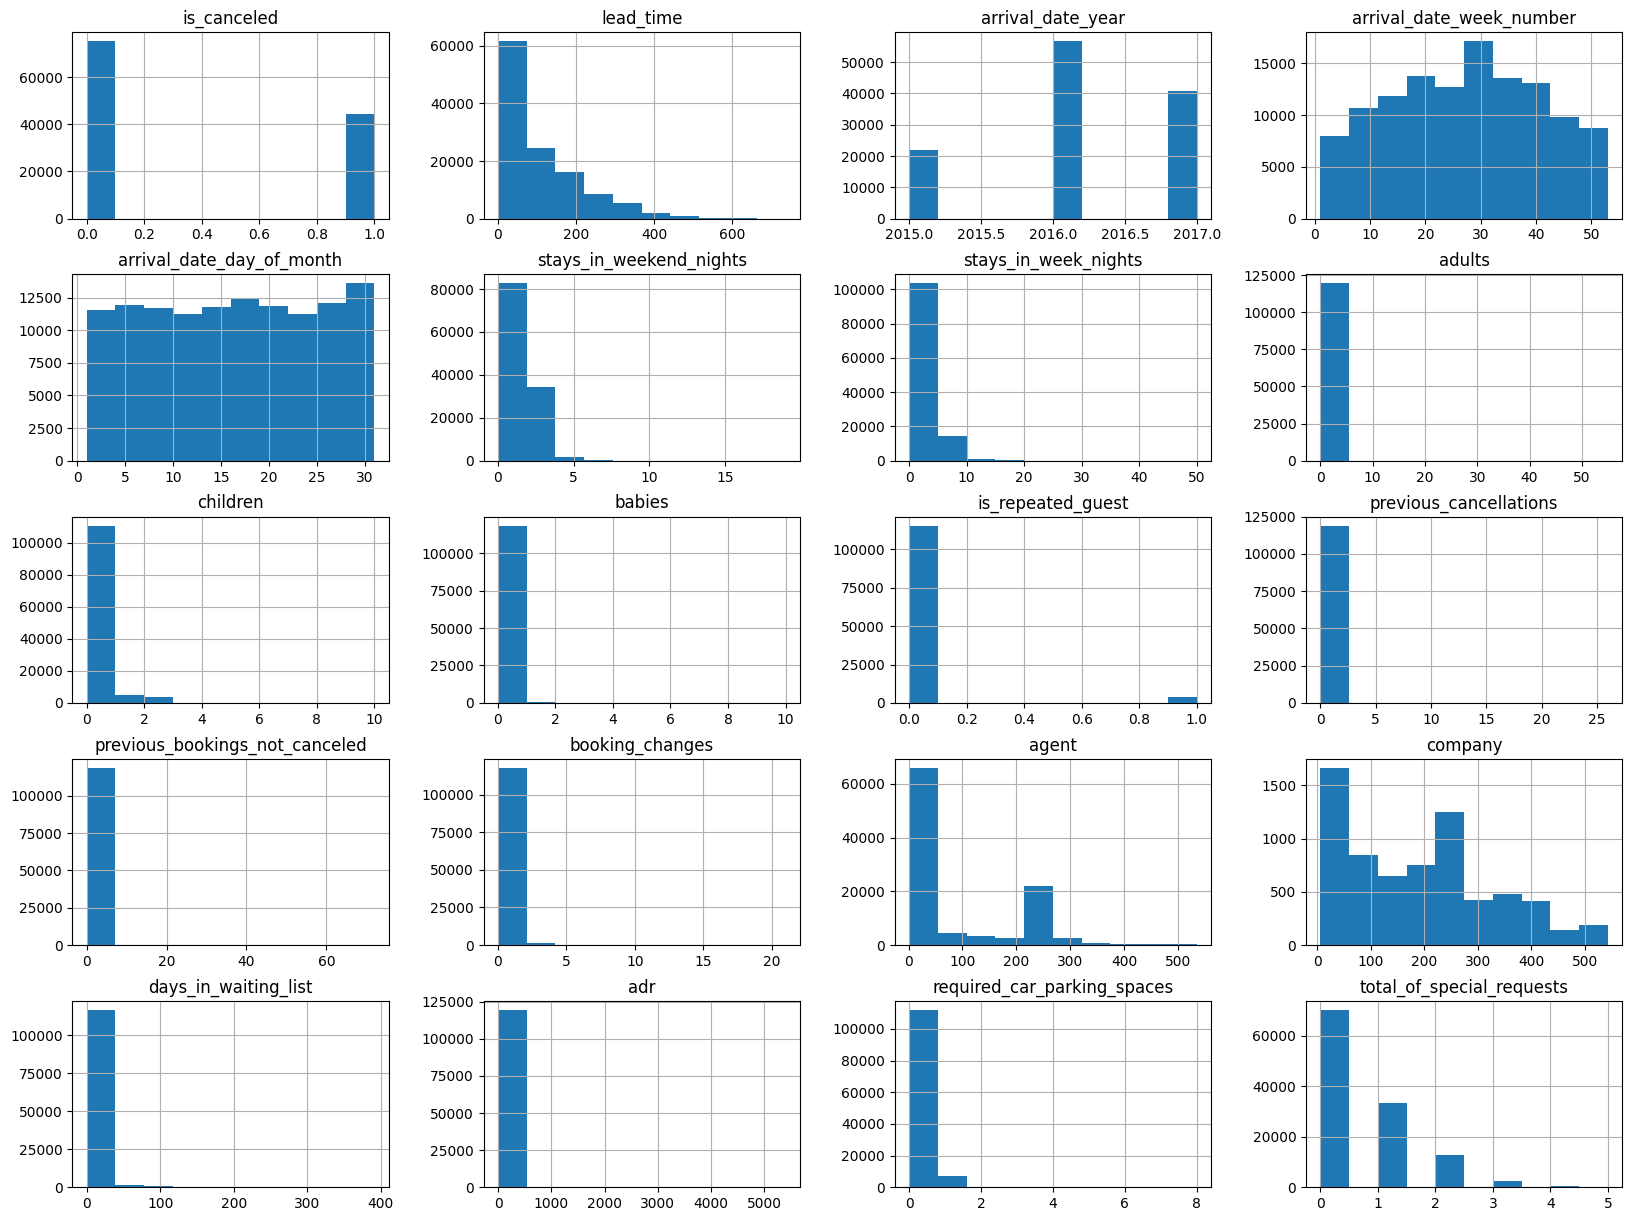

In [5]:
# histogram grid for numeric columns
df.hist(figsize=(20, 15))
plt.show()

- lead_time is highly right-skewed, meaning most bookings are made relatively close to arrival, but some are booked very far in advance.

- stays_in_week_nights and stays_in_weekend_nights are concentrated at low values, showing that most guests stay only a few nights.

- previous_cancellations, previous_bookings_not_canceled, and booking_changes are heavily concentrated at zero, meaning most guests have no prior booking history or changes.

- is_repeated_guest is highly imbalanced, with most guests being new rather than returning.

- adr (average daily rate) shows a wide spread and extreme outliers, suggesting possible high-price bookings.

- days_in_waiting_list is mostly zero, indicating that most bookings were not on a waiting list.

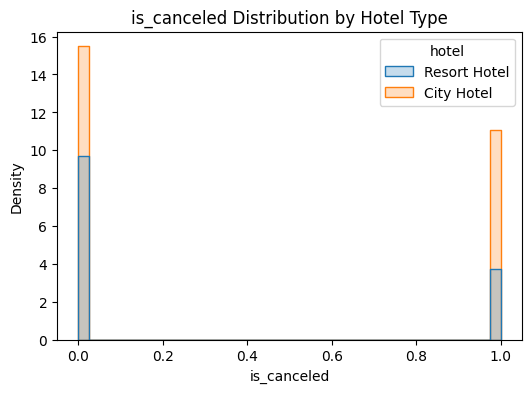

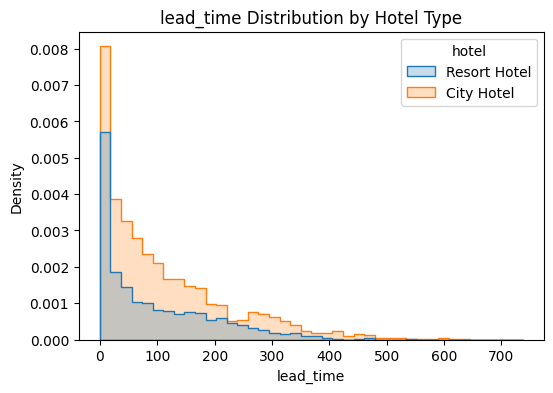

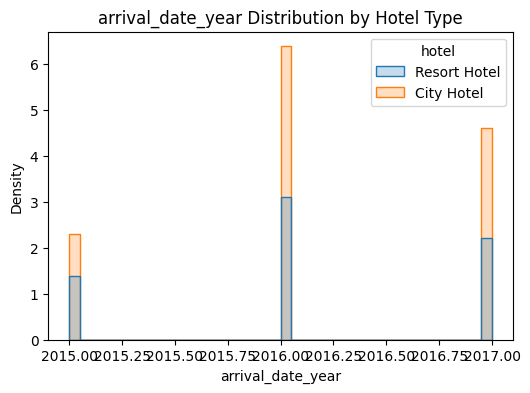

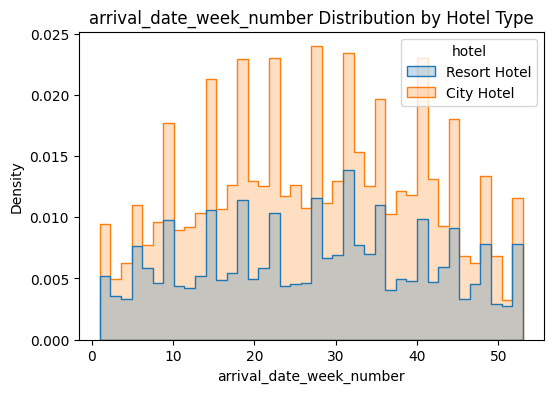

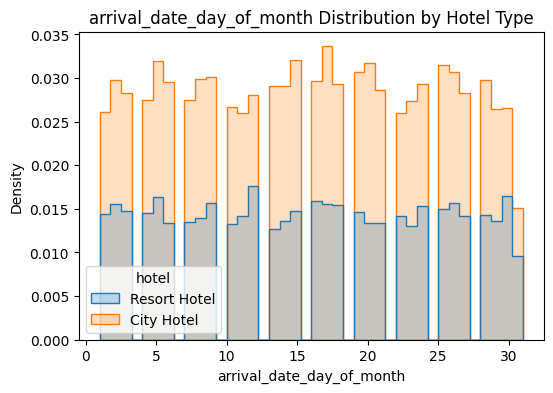

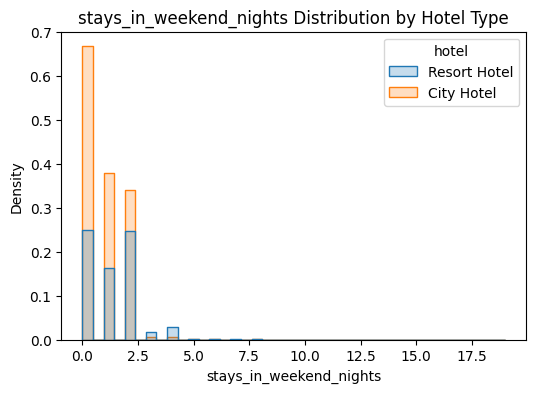

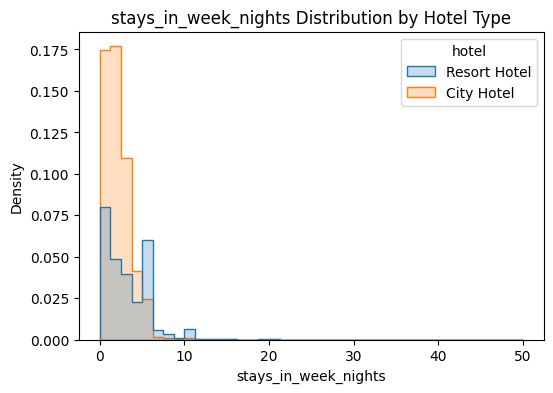

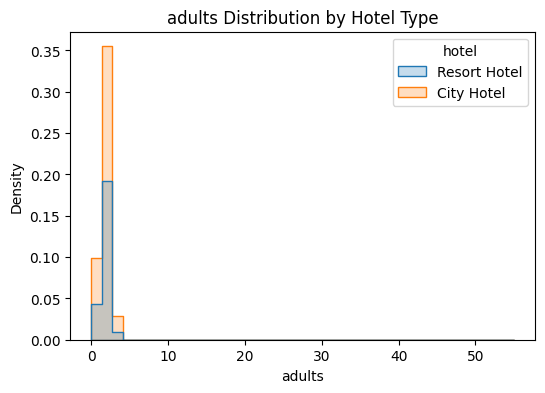

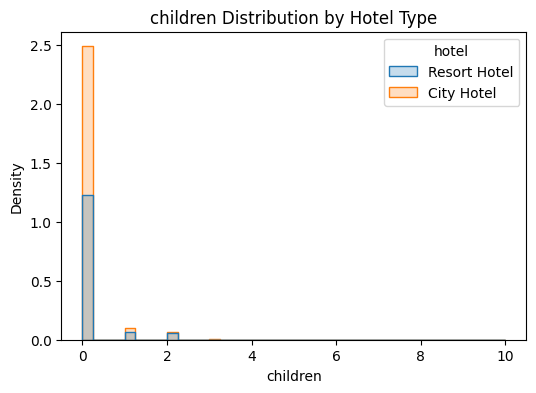

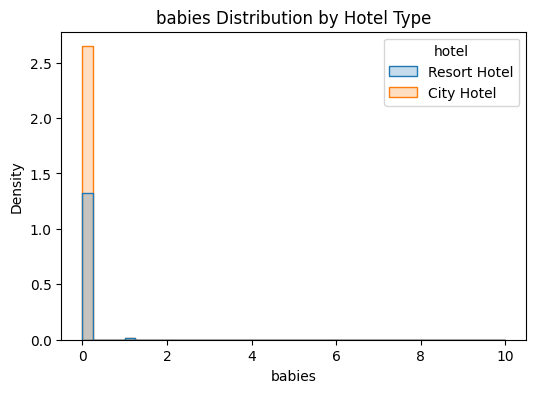

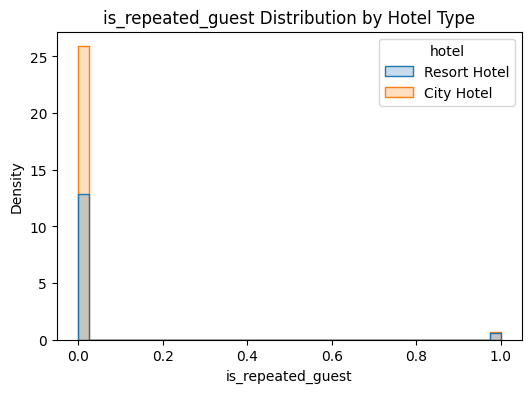

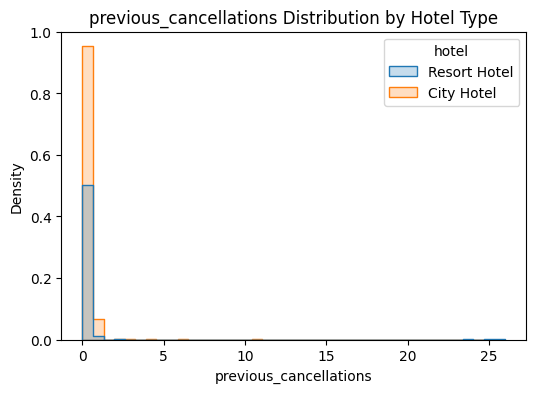

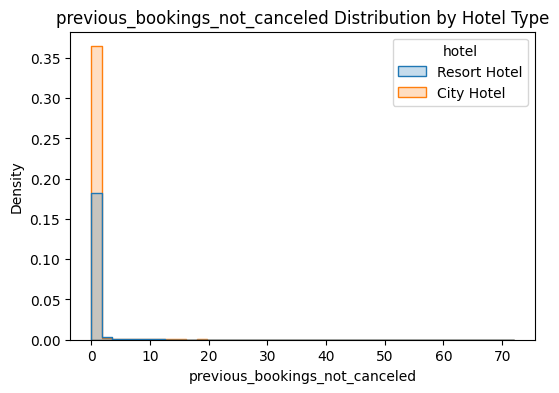

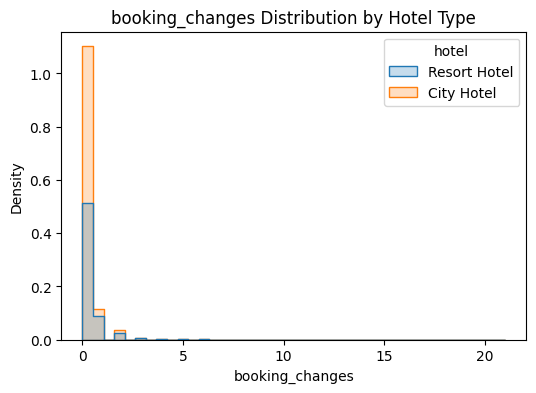

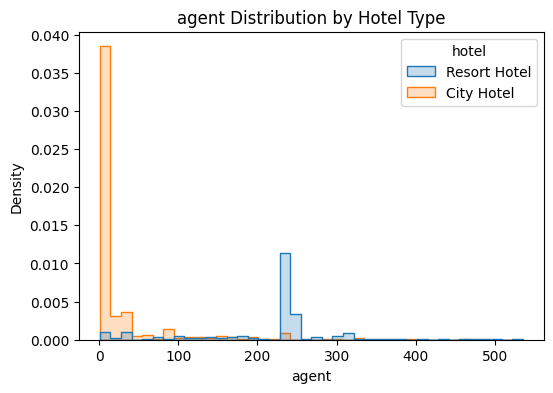

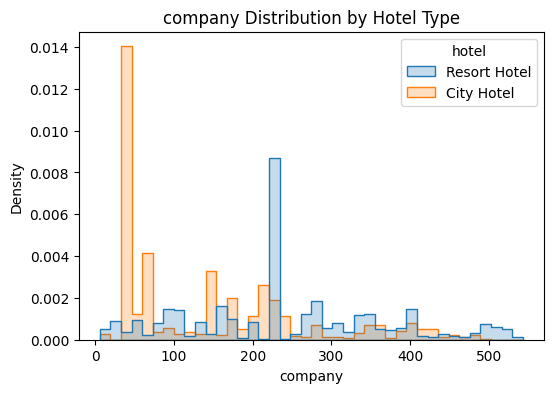

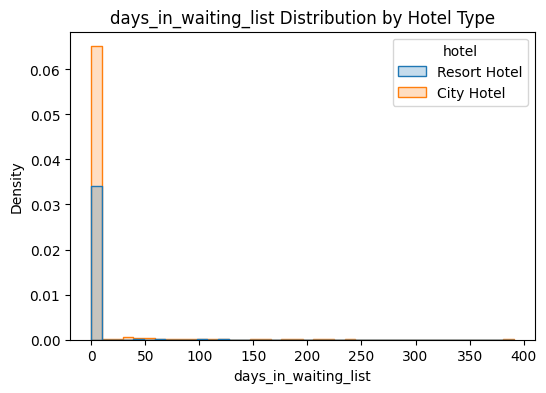

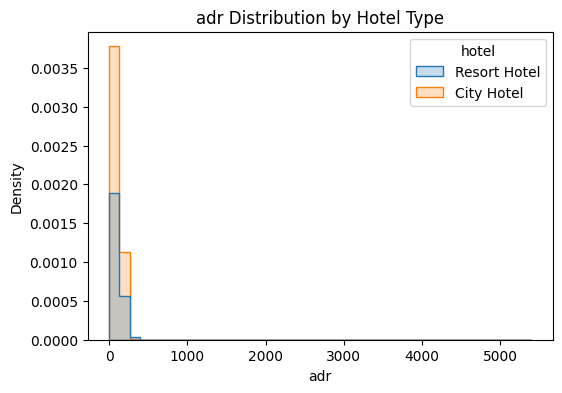

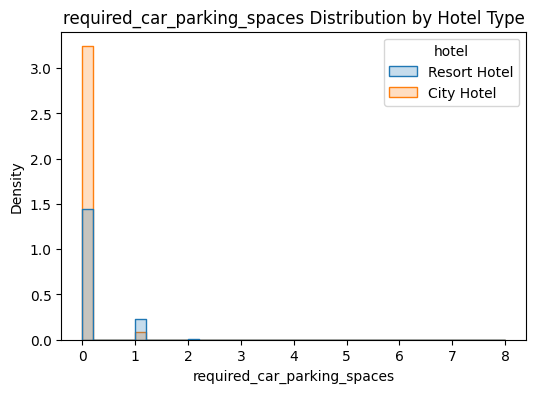

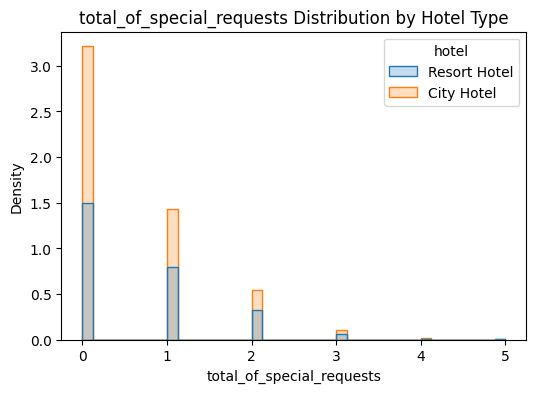

In [6]:
# look at city hotel and resort hotel seperatly
df_city = df[df["hotel"] == "City Hotel"]
df_resort = df[df["hotel"] == "Resort Hotel"]

numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(
        data=df,
        x=col,
        hue="hotel",
        bins=40,
        stat="density",
        element="step"
    )
    plt.title(f"{col} Distribution by Hotel Type")
    plt.show()

## 2.2 Booking and Cancel Rate by Hotel

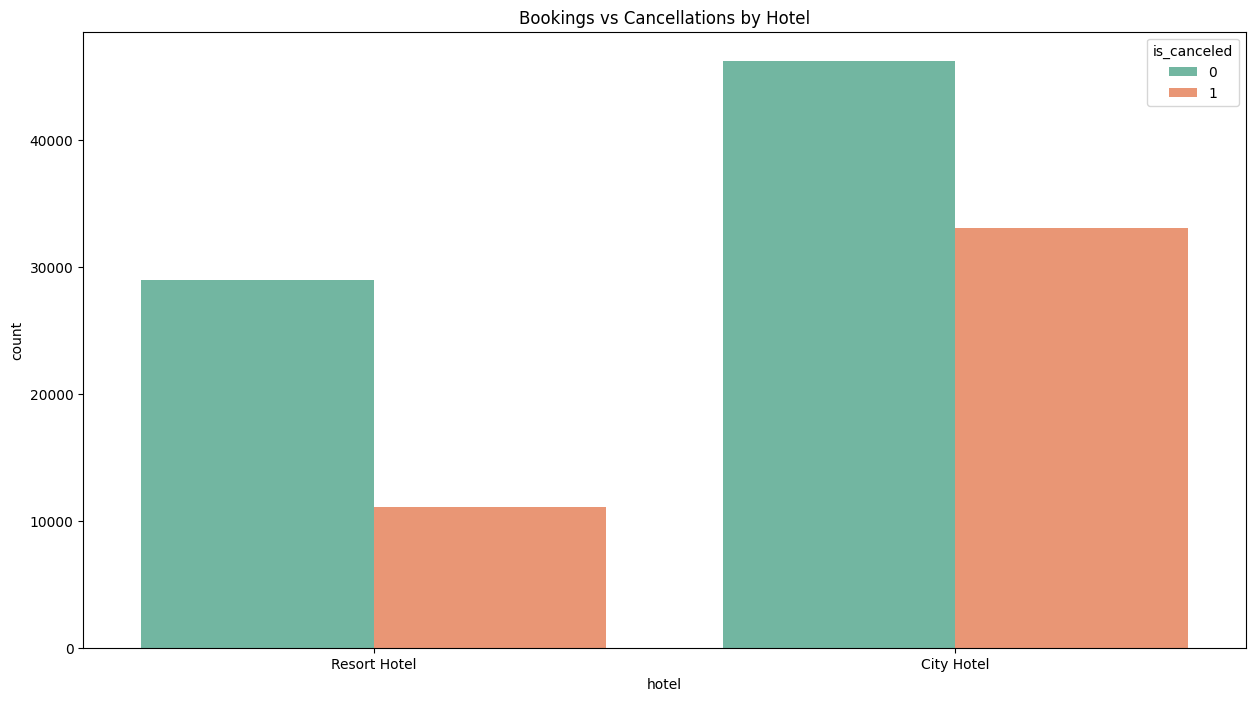

 Hotel Cancel Rate  
hotel
City Hotel      0.417270
Resort Hotel    0.277634
Name: count, dtype: float64


In [7]:
plt.figure(figsize=(15,8))
sns.countplot(x="hotel", data=df, hue="is_canceled", palette=sns.color_palette("Set2", 2))
plt.title("Bookings vs Cancellations by Hotel")
plt.show()

# cancel rate by hotel (like your printed output)
hotel_cancel = df.loc[df["is_canceled"]==1, "hotel"].value_counts() / df["hotel"].value_counts()
print("Hotel Cancel Rate".center(20), hotel_cancel, sep="\n")

## 2.3 Booking Patterns for Seasonality

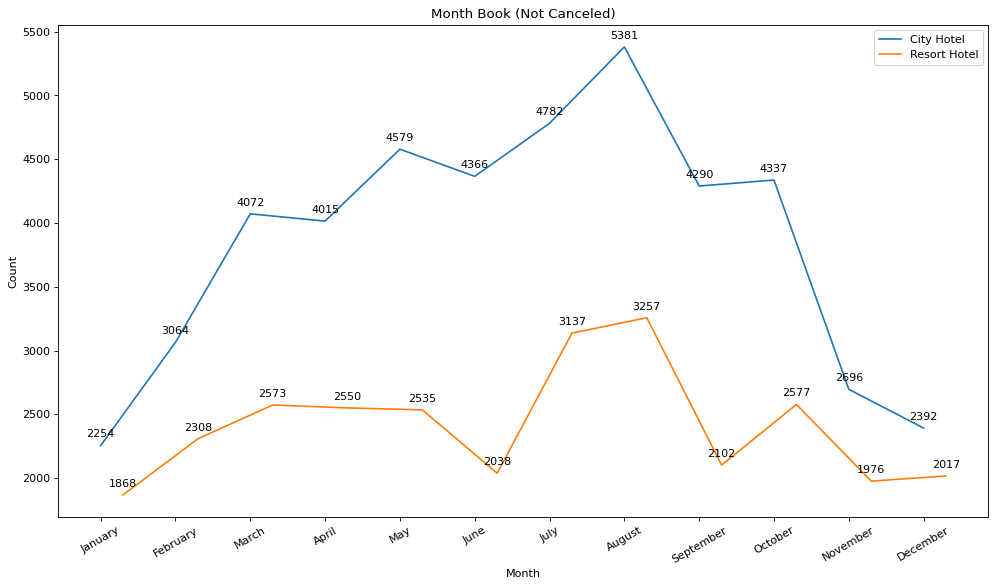

In [8]:
city_hotel   = df[(df["hotel"]=="City Hotel") & (df["is_canceled"]==0)].copy()
resort_hotel = df[(df["hotel"]=="Resort Hotel") & (df["is_canceled"]==0)].copy()

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

city_month   = city_hotel["arrival_date_month"].value_counts().reindex(month_order)
resort_month = resort_hotel["arrival_date_month"].value_counts().reindex(month_order)

x  = np.arange(len(month_order))
x1 = x + 0.3
width = 0.3

plt.figure(figsize=(15,8), dpi=80)
plt.plot(x,  city_month.values,   label="City Hotel")
plt.plot(x1, resort_month.values, label="Resort Hotel")
plt.xticks(x, month_order, rotation=30)
plt.xlabel("Month")
plt.ylabel("Count")
plt.title("Month Book (Not Canceled)")
plt.legend()

for xx, yy in zip(x, city_month.values):
    plt.text(xx, yy+50, f"{int(yy)}", ha="center", va="bottom")
for xx, yy in zip(x1, resort_month.values):
    plt.text(xx, yy+50, f"{int(yy)}", ha="center", va="bottom")

plt.show()

- Both Resort Hotel and City Hotel show strong demand during the summer months, especially in July and August.


## 2.4 Customer Types and Booking Types

- Transient – Individual travelers booking independently (not part of a group or contract).

- Transient-Party – Individual travelers booking together as a small party, but not under a formal group contract.

- Contract – Bookings made under a negotiated contract, usually by companies or institutions.

- Group – Bookings made as part of a larger organized group (e.g., tour groups, events, conferences).

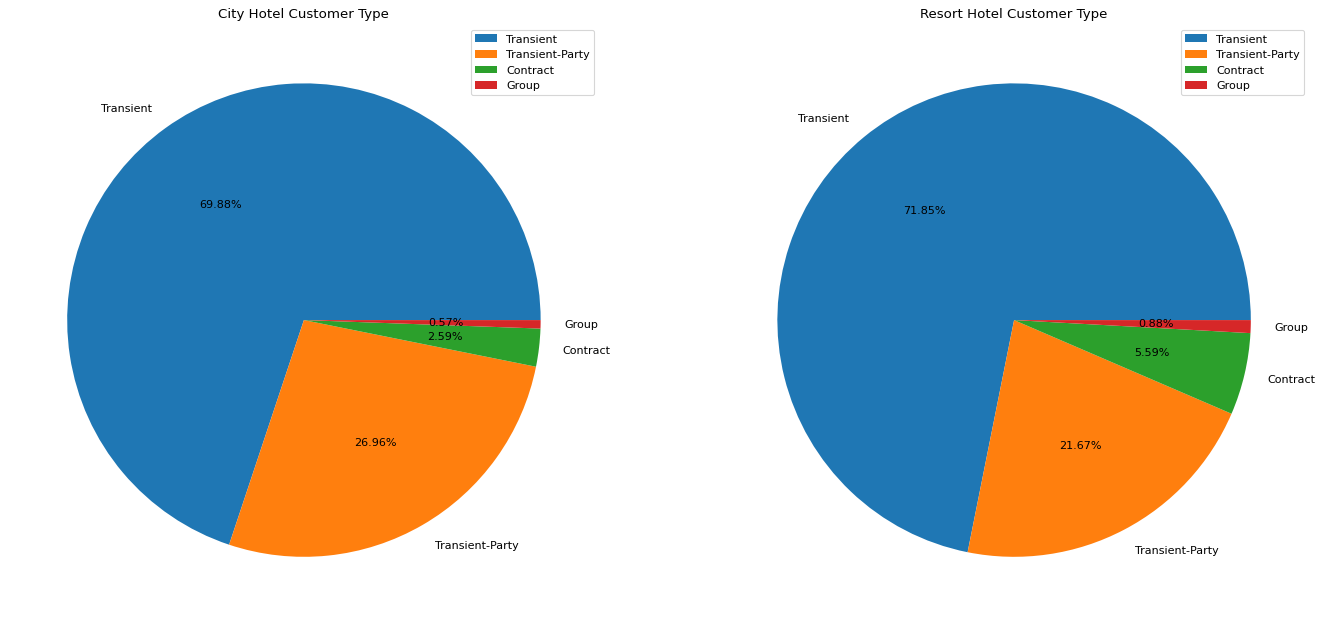

In [9]:
city_customer   = city_hotel["customer_type"].value_counts()
resort_customer = resort_hotel["customer_type"].value_counts()

plt.figure(figsize=(21,12), dpi=80)

plt.subplot(1,2,1)
plt.pie(city_customer, labels=city_customer.index, autopct="%.2f%%")
plt.legend(loc=1)
plt.title("City Hotel Customer Type")

plt.subplot(1,2,2)
plt.pie(resort_customer, labels=resort_customer.index, autopct="%.2f%%")
plt.legend()
plt.title("Resort Hotel Customer Type")

plt.show()

- Online TA – Booking made through an online travel agency (e.g., Booking.com, Expedia).

- Offline TA/TO – Booking made through an offline travel agency or tour operator.

- Direct – Customer booked directly with the hotel (website, phone, etc.).

- Groups – Booking made as part of an organized group.

- Corporate – Booking made by a company for business purposes.

- Complementary – Free bookings (no charge), often for promotions or VIP guests.

- Aviation – Bookings related to airline crew or aviation-related stays.

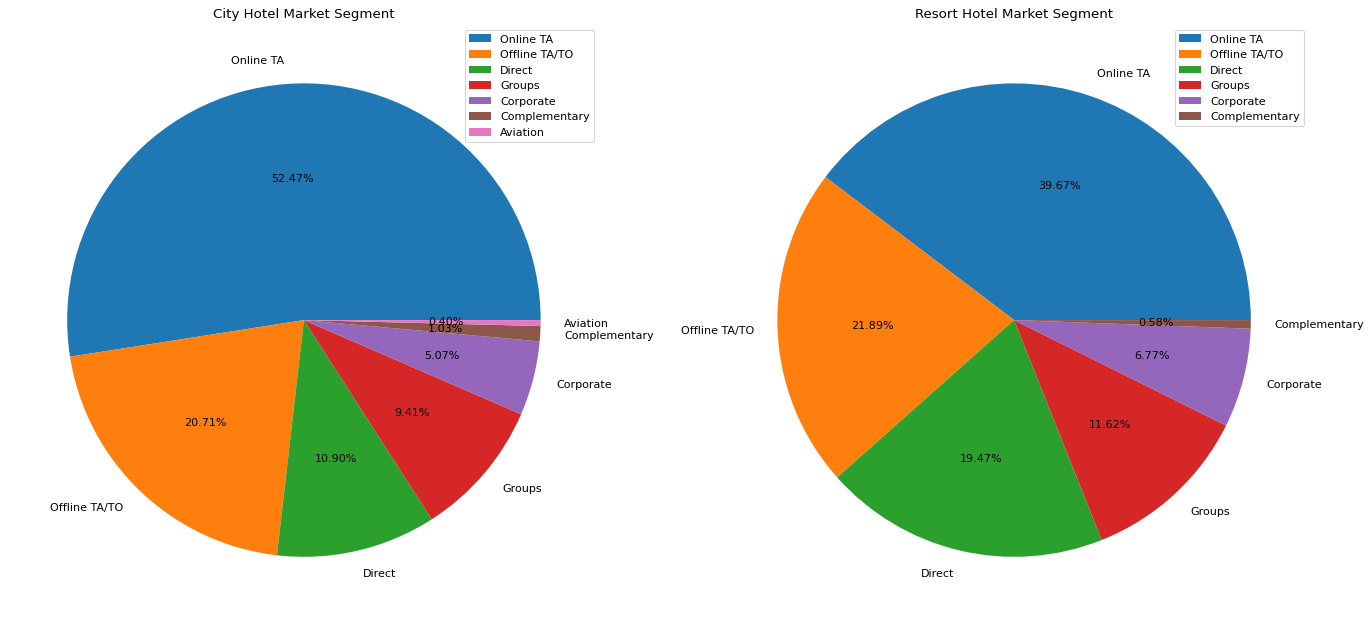

In [10]:
city_segment   = city_hotel["market_segment"].value_counts()
resort_segment = resort_hotel["market_segment"].value_counts()

plt.figure(figsize=(21,12), dpi=80)

plt.subplot(1,2,1)
plt.pie(city_segment, labels=city_segment.index, autopct="%.2f%%")
plt.legend()
plt.title("City Hotel Market Segment")

plt.subplot(1,2,2)
plt.pie(resort_segment, labels=resort_segment.index, autopct="%.2f%%")
plt.legend()
plt.title("Resort Hotel Market Segment")

plt.show()

## 2.5 Cancellation Behavior

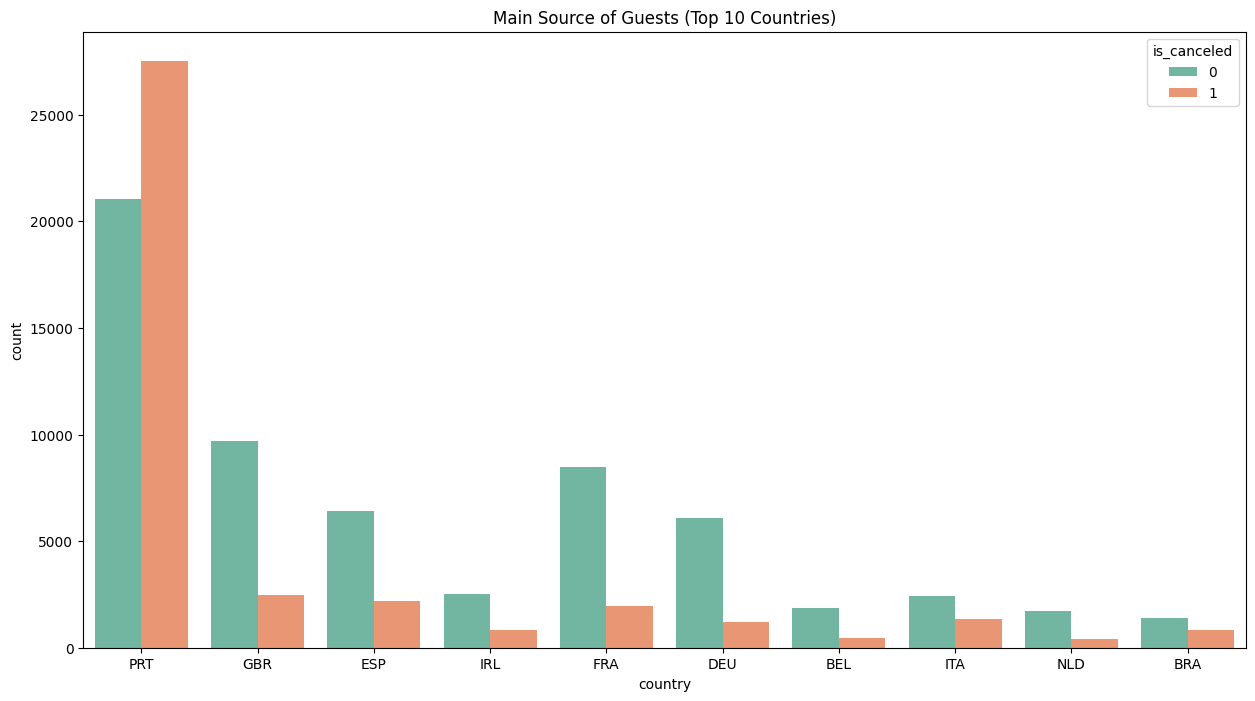

cancel rate by country
country
PRT    0.566351
BRA    0.373201
ITA    0.353956
ESP    0.254085
IRL    0.246519
BEL    0.202391
GBR    0.202243
FRA    0.185694
NLD    0.183935
DEU    0.167147
Name: count, dtype: float64


In [11]:
country_book = df["country"].value_counts()[:10]
country_cancel = df[(df["country"].isin(country_book.index)) & (df["is_canceled"]==1)]["country"].value_counts()

plt.figure(figsize=(15,8))
sns.countplot(
    x="country",
    data=df[df["country"].isin(country_book.index)],
    hue="is_canceled",
    palette=sns.color_palette("Set2", 2)
)
plt.title("Main Source of Guests (Top 10 Countries)")
plt.show()

country_cancel_rate = (country_cancel / country_book).sort_values(ascending=False)
print("cancel rate by country".center(10), country_cancel_rate, sep="\n")

- Among the main customer source countries, Portugal (PRT) has the highest cancellation rate, followed by Brazil (BRA) and Italy (ITA).
- The United Kingdom is also a major source of customers, although its cancellation rate is lower compared to Portugal.

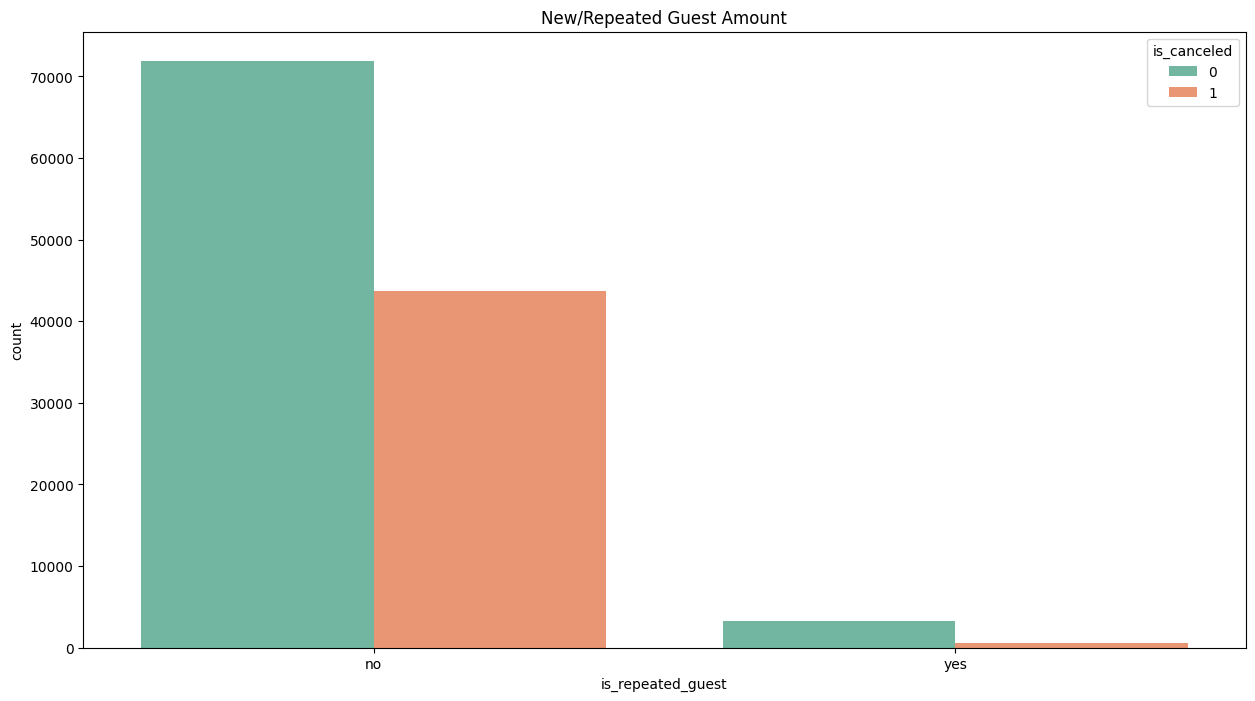

cancellation rate: new guests vs. repeated guests
New Guest         0.377851
Repeated Guest    0.144882
Name: count, dtype: float64


In [12]:
plt.figure(figsize=(15,8))
sns.countplot(
    x="is_repeated_guest",
    data=df,
    hue="is_canceled",
    palette=sns.color_palette("Set2", 2)
)
plt.title("New/Repeated Guest Amount")
plt.xticks(range(2), ["no", "yes"])
plt.show()

guest_cancel = (
    df.loc[df["is_canceled"]==1, "is_repeated_guest"].value_counts()
    / df["is_repeated_guest"].value_counts()
)
guest_cancel.index = ["New Guest", "Repeated Guest"]  # match your label style
print("cancellation rate: new guests vs. repeated guests".center(15), guest_cancel, sep="\n")

# Non Refund → should have very LOW cancellation rate ==> suspicious need to be checked (I dropped it but maybe run a test model without deposit_type

In [13]:
pd.crosstab(df["deposit_type"], df["is_canceled"], normalize="index")

is_canceled,0,1
deposit_type,,
No Deposit,0.716230,0.283770
Non Refund,0.006376,0.993624
Refundable,0.777778,0.222222


3 Deposit types
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64


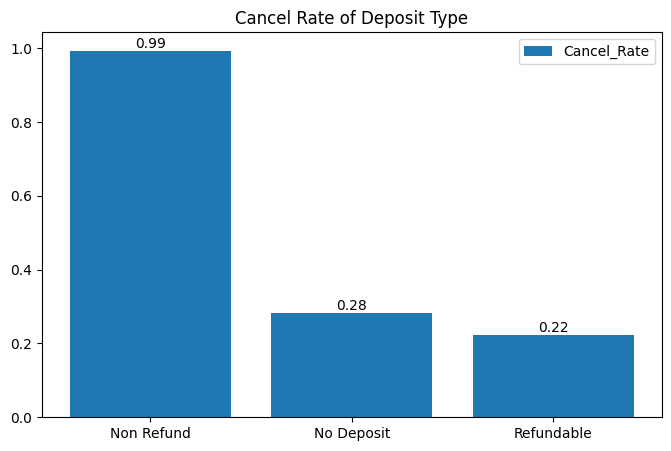

Cancellation rate by deposit type
deposit_type
Non Refund    0.993624
No Deposit    0.283770
Refundable    0.222222
Name: count, dtype: float64


In [14]:


print("3 Deposit types".center(15), df["deposit_type"].value_counts(), sep="\n")

deposit_cancel = (
    df.loc[df["is_canceled"]==1, "deposit_type"].value_counts()
    / df["deposit_type"].value_counts()
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
x = np.arange(len(deposit_cancel.index))
y = deposit_cancel.values
plt.bar(x, y, label="Cancel_Rate")
plt.xticks(x, deposit_cancel.index)
plt.legend()
plt.title("Cancel Rate of Deposit Type")

for xx, yy in zip(x, y):
    plt.text(xx, yy, f"{yy:.2f}", ha="center", va="bottom")

plt.show()

print("Cancellation rate by deposit type".center(15), deposit_cancel, sep="\n")

# 3. Split data, Set X and Y

- We decide that “is_canceled” is the variable we want to predict.

- We make a copy of the original data so we don’t accidentally change it.

- We remove columns like reservation_status and reservation_status_date because they contain information that happens after the booking outcome. Keeping them would make the model unfairly “cheat.”

- We separate the data into two parts:

- X → all the input features (what the model uses to learn)

- y → the target variable (whether the booking was canceled or not)



- We split the dataset into training and testing sets before any preprocessing.
- We do a 80/20 split


In [15]:

TARGET = "is_canceled"

df_clean = df.copy()
df_clean = df_clean.drop(
    columns=[c for c in ["reservation_status_date", "reservation_status", "deposit_type"] if c in df_clean.columns],
    errors="ignore"
)

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET].astype(int)

In [16]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Proprocessing/Feature Engineering

## 4.2 Missing Value and Convert Catagorial Variable

- Reduce unnecessary complexity by removing detailed agent and company ID numbers.

- Instead of keeping many different agent/company identifiers, we simplify them into clear YES/NO indicators (was an agent involved? was a company involved?).

- This makes the model easier to interpret

The function:
- Fills missing agent and company with 0 (meaning no agent/company involved).

- Fills missing country with the most common country.

- Creates in_company → whether a company was involved (YES/NO).

- Creates in_agent → whether an agent was involved (YES/NO).

- Creates same_assignment → whether the guest received the room they reserved.

- Converts is_repeated_guest from 0/1 into clearer labels (NO/YES).

- Removes the original raw ID and room type columns since we replaced them with cleaner features.


In [17]:
# ------------------------------------------------------------
# 1) Feature Engineering (light but useful)
# Justification: creates compact, interpretable signals (stay length, guests, deposit, etc.)
# ------------------------------------------------------------
def engineer_features(X):
    X = X.copy()

    # --- Missing values ---
    # agent/company: treat missing as 0 = "not involved"
    if {"agent", "company"}.issubset(X.columns):
        X[["agent", "company"]] = X[["agent", "company"]].fillna(0)

    # country: fill missing with most common country (mode)
    if "country" in X.columns and X["country"].isnull().any():
        X["country"] = X["country"].fillna(X["country"].mode()[0])

    # --- Create YES/NO features ---
    # Was there a company involved?
    if "company" in X.columns:
        X["in_company"] = np.where(X["company"] == 0, "NO", "YES")

    # Was there an agent involved?
    if "agent" in X.columns:
        X["in_agent"] = np.where(X["agent"] == 0, "NO", "YES")

    # Did reserved room match assigned room?
    if {"reserved_room_type", "assigned_room_type"}.issubset(X.columns):
        X["same_assignment"] = np.where(
            X["reserved_room_type"] == X["assigned_room_type"], "YES", "NO"
        )

    # Convert is_repeated_guest 0/1 -> NO/YES (categorical label)
    if "is_repeated_guest" in X.columns:
        X["is_repeated_guest"] = X["is_repeated_guest"].replace({0: "NO", 1: "YES"})

    # --- Drop raw columns we replaced ---
    X = X.drop(
        columns=[c for c in ["reserved_room_type", "assigned_room_type", "agent", "company"] if c in X.columns],
        errors="ignore"
    )

    return X

In [18]:
X_train = engineer_features(X_train_raw)
X_test  = engineer_features(X_test_raw)

In [19]:
X_train.head()


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,in_company,in_agent,same_assignment
105447,City Hotel,20,2017,February,6,7,0,2,1,0.0,0,BB,IRL,Online TA,GDS,NO,0,0,0,0,Transient,98.0,0,0,YES,YES,YES
85242,City Hotel,8,2016,March,11,9,0,3,2,0.0,0,BB,FRA,Groups,TA/TO,NO,0,0,0,0,Transient-Party,100.0,0,0,NO,NO,YES
65604,City Hotel,93,2017,April,14,6,0,3,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,NO,0,0,0,0,Transient,95.0,0,0,NO,YES,YES
17345,Resort Hotel,90,2015,September,39,23,4,10,2,0.0,0,BB,GBR,Offline TA/TO,TA/TO,NO,0,0,0,0,Contract,54.0,0,0,NO,YES,YES
117786,City Hotel,8,2017,August,32,9,0,1,1,0.0,0,BB,ESP,Corporate,Corporate,NO,0,0,0,0,Transient,80.0,0,0,YES,NO,YES


## 4.3 Correlation with Target
- Here is a quik check on how each feature is related to whether a booking was canceled
- If to do all features at once, Since categorical variables are text, we need to encode them numerically to compute correlation.
- but the ordinal encodnign assign fake numeric order so we chose to do categorial and numeric seperate.


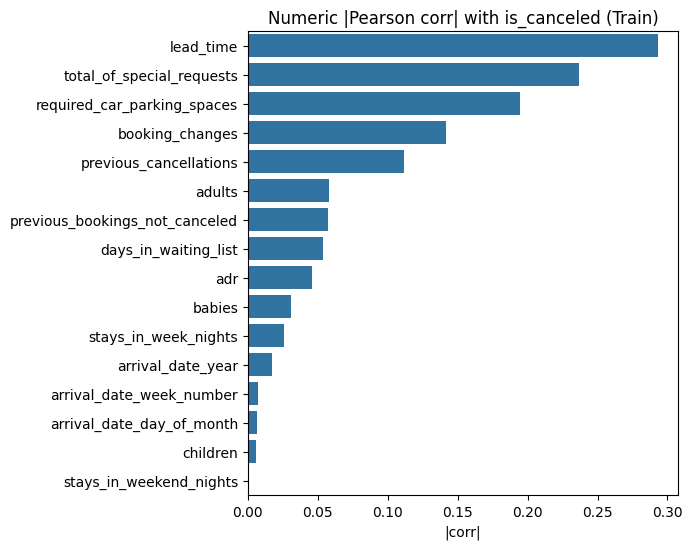

In [20]:
# Justification:
# - Pearson correlation is meaningful only for numeric features
# - Categorical vs binary target → use Cramér’s V (not ordinal encoding)
# This is EDA only; does not change the modeling pipeline.

# --- Numeric correlation with target (Pearson) ---
num_cols_tmp = X_train.select_dtypes(exclude="object").columns.tolist()
if len(num_cols_tmp) > 0:
    df_num = pd.concat([X_train[num_cols_tmp], y_train.rename(TARGET)], axis=1)
    corr = df_num.corr(numeric_only=True)
    cor_target = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)

    plt.figure(figsize=(7, max(5, 0.35 * len(cor_target))))
    sns.barplot(x=cor_target.values, y=cor_target.index)
    plt.title("Numeric |Pearson corr| with is_canceled (Train)")
    plt.xlabel("|corr|")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

- Lead time has the strongest linear relationship with cancellations, meaning bookings made far in advance are more likely to cancel.

- Total special requests and required car parking spaces are also strongly related, suggesting more committed bookings cancel less often.

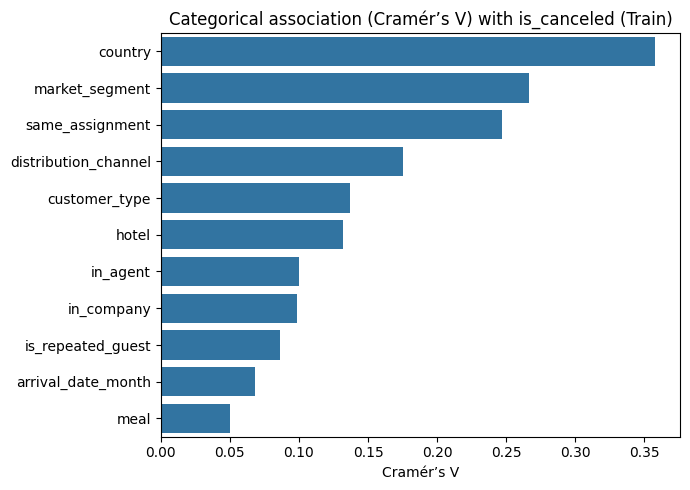

In [21]:
# --- Categorical association with target (Cramér’s V) ---
def cramers_v(x, y_):
    ct = pd.crosstab(x, y_)
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return 0.0
    chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum()
    r, k = ct.shape
    return float(np.sqrt((chi2 / n) / (min(r - 1, k - 1) + 1e-12)))

cat_cols_tmp = X_train.select_dtypes(include="object").columns.tolist()
if len(cat_cols_tmp) > 0:
    cramers = pd.Series({c: cramers_v(X_train[c], y_train) for c in cat_cols_tmp}).sort_values(ascending=False)

    plt.figure(figsize=(7, max(5, 0.35 * len(cramers))))
    sns.barplot(x=cramers.values, y=cramers.index)
    plt.title("Categorical association (Cramér’s V) with is_canceled (Train)")
    plt.xlabel("Cramér’s V")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

- Deposit type shows the strongest association with cancellation, indicating payment structure strongly affects cancellation behavior.

- Country and market segment also have notable associations, meaning cancellation rates differ across groups.

- Features like same_assignment and distribution_channel show moderate relationships.

## 4.4 Identify column types
- automatically separates numeric and categorical features so they can be preprocessed appropriately without manual specification.

In [22]:
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

In [23]:
print("Categorical columns:")
print(cat_cols)

print("\nNumeric columns:")
print(num_cols)

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'customer_type', 'in_company', 'in_agent', 'same_assignment']

Numeric columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


## 4.5 Data Preprocessing and Feature Encoding

For numeric columns, we:

- fill missing values with the median (stable even if there are outliers),

- then standardize them (put them on the same scale), which helps Logistic Regression train more reliably.

For categorical columns, we:

- fill missing values with the most common category,

- then use one-hot encoding so categories become 0/1 columns without creating a fake numeric order.


We avoided heavy transformations because Random Forest can naturally handle non-linear patterns and skewed distributions.


In [24]:
# Build preprocessing (model-ready)
# - Numeric: median impute + standardize (helps logistic; RF doesn’t need scaling but is fine)
# - Categorical: mode impute + one-hot encode (no fake ordering)
preprocess = ColumnTransformer(
    transformers=[
        # ----- Numeric Features -----
        ("num", Pipeline([
            # Fill missing numeric values using median (robust to outliers)
            ("imputer", SimpleImputer(strategy="median")),

            # Standardize numeric features (mean=0, std=1)
            # Important for Logistic Regression; harmless for Random Forest
            ("scaler", StandardScaler())
        ]), num_cols),

        # ----- Categorical Features -----
        ("cat", Pipeline([
            # Fill missing categorical values with most frequent category
            ("imputer", SimpleImputer(strategy="most_frequent")),

            # Convert categories into 0/1 columns
            # drop="first" avoids perfect multicollinearity
            # handle_unknown="ignore" prevents errors if new categories appear
            ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

# Fit preprocessing ONLY on training data (prevents data leakage)
X_train_enc = preprocess.fit_transform(X_train)

# Apply the same learned transformations to test data
X_test_enc  = preprocess.transform(X_test)

# Get final feature names after encoding
feature_names = preprocess.get_feature_names_out()

# Print shapes to confirm transformation worked
print("Train shape:", X_train_enc.shape)
print("Test shape:", X_test_enc.shape)

Train shape: (95512, 221)
Test shape: (23878, 221)


In [25]:
print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

Numeric features: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical features: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'customer_type', 'in_company', 'in_agent', 'same_assignment']


In [26]:
pd.DataFrame.sparse.from_spmatrix(
    X_train_enc,
    columns=feature_names
).head()

,num__lead_time,num__arrival_date_year,num__arrival_date_week_number,num__arrival_date_day_of_month,num__stays_in_weekend_nights,num__stays_in_week_nights,num__adults,num__children,num__babies,num__previous_cancellations,num__previous_bookings_not_canceled,num__booking_changes,num__days_in_waiting_list,num__adr,num__required_car_parking_spaces,num__total_of_special_requests,cat__hotel_Resort Hotel,cat__arrival_date_month_August,cat__arrival_date_month_December,cat__arrival_date_month_February,cat__arrival_date_month_January,cat__arrival_date_month_July,cat__arrival_date_month_June,cat__arrival_date_month_March,cat__arrival_date_month_May,cat__arrival_date_month_November,cat__arrival_date_month_October,cat__arrival_date_month_September,cat__meal_FB,cat__meal_HB,cat__meal_SC,cat__meal_Undefined,cat__country_AGO,cat__country_AIA,cat__country_ALB,cat__country_AND,cat__country_ARE,cat__country_ARG,cat__country_ARM,cat__country_ASM,cat__country_ATA,cat__country_ATF,cat__country_AUS,cat__country_AUT,cat__country_AZE,cat__country_BEL,cat__country_BEN,cat__country_BFA,cat__country_BGD,cat__country_BGR,...,cat__country_SGP,cat__country_SLE,cat__country_SLV,cat__country_SMR,cat__country_SRB,cat__country_STP,cat__country_SUR,cat__country_SVK,cat__country_SVN,cat__country_SWE,cat__country_SYC,cat__country_SYR,cat__country_TGO,cat__country_THA,cat__country_TJK,cat__country_TMP,cat__country_TUN,cat__country_TUR,cat__country_TWN,cat__country_TZA,cat__country_UGA,cat__country_UKR,cat__country_UMI,cat__country_URY,cat__country_USA,cat__country_UZB,cat__country_VEN,cat__country_VGB,cat__country_VNM,cat__country_ZAF,cat__country_ZMB,cat__country_ZWE,cat__market_segment_Complementary,cat__market_segment_Corporate,cat__market_segment_Direct,cat__market_segment_Groups,cat__market_segment_Offline TA/TO,cat__market_segment_Online TA,cat__market_segment_Undefined,cat__distribution_channel_Direct,cat__distribution_channel_GDS,cat__distribution_channel_TA/TO,cat__distribution_channel_Undefined,cat__is_repeated_guest_YES,cat__customer_type_Group,cat__customer_type_Transient,cat__customer_type_Transient-Party,cat__in_company_YES,cat__in_agent_YES,cat__same_assignment_YES
0,-0.784882,1.193298,-1.552382,-1.000803,-0.928908,-0.261137,-1.464604,-0.259968,-0.078866,-0.104002,-0.091345,-0.335916,-0.132847,-0.074093,-0.253754,-0.720366,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,1.0,0,0,0,0,1.0,0,1.0,1.0,1.0
1,-0.897168,-0.221372,-1.185007,-0.773337,-0.928908,0.262232,0.246367,-0.259968,-0.078866,-0.104002,-0.091345,-0.335916,-0.132847,-0.034887,-0.253754,-0.720366,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,1.0,0,0,0,0,1.0,0,0,1.0
2,-0.101806,1.193298,-0.964581,-1.114537,-0.928908,0.262232,0.246367,-0.259968,-0.078866,-0.104002,-0.091345,-0.335916,-0.132847,-0.132903,-0.253754,-0.720366,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,1.0,0,0,0,1.0,0,0,1.0,1.0
3,-0.129877,-1.636041,0.872297,0.818927,3.077406,3.925816,0.246367,-0.259968,-0.078866,-0.104002,-0.091345,-0.335916,-0.132847,-0.936631,-0.253754,-0.720366,1.0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,1.0,0,0,0,0,0,0,1.0,1.0
4,-0.897168,1.193298,0.357971,-0.773337,-0.928908,-0.784506,-1.464604,-0.259968,-0.078866,-0.104002,-0.091345,-0.335916,-0.132847,-0.42695,-0.253754,-0.720366,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,1.0,0,1.0


## Multicollinearity

Multicollinearity was controlled through careful encoding (dropping reference categories), feature simplification,making dimensionality reduction through PCA unnecessary.
# PCA Demonstration (No Impact on Model Pipeline)

Even though PCA shows dimensionality reduction is possible:

- Random Forest does not require uncorrelated features.

- Logistic Regression worked well without PCA.

- PCA removes interpretability (components lose business meaning).

So this PCA step is purely exploratory and confirms that dimensionality reduction is not necessary for our modeling approach.



In [27]:
# Convert to dense if sparse (PCA requires dense matrix)
if hasattr(X_train_enc, "toarray"):
    X_dense = X_train_enc.toarray()
else:
    X_dense = X_train_enc

# Fit PCA on training data
pca = PCA()
pca.fit(X_dense)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\nFirst 10 principal components variance:")
for i in range(10):
    print(f"PC{i+1}: {explained_variance[i]:.4f}")

print("\nCumulative variance (first 10 PCs):")
print(cumulative_variance[:10])


First 10 principal components variance:
PC1: 0.0996
PC2: 0.0869
PC3: 0.0754
PC4: 0.0667
PC5: 0.0573
PC6: 0.0557
PC7: 0.0523
PC8: 0.0504
PC9: 0.0488
PC10: 0.0457

Cumulative variance (first 10 PCs):
[0.09956805 0.18644745 0.2618457  0.32852988 0.38586226 0.44152044
 0.49380916 0.54418856 0.59294544 0.63861527]



***Interpretation:***

The first principal component (PC1) explains about 10% of the total variance.

The first 5 components together explain about 39%.

The first 10 components explain about 64% of the variance.

This means no single component dominates — variance is spread across many features.

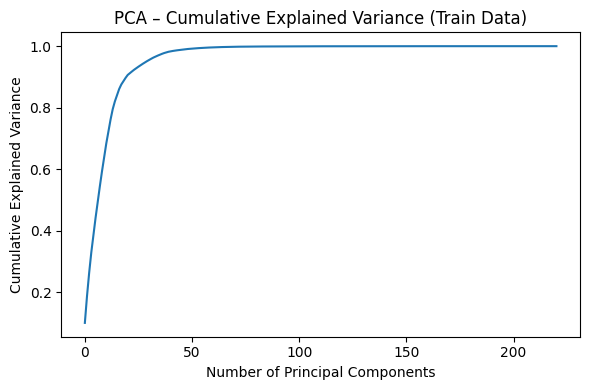

In [28]:
plt.figure(figsize=(6,4))
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA – Cumulative Explained Variance (Train Data)")
plt.tight_layout()
plt.show()

# 5. Baseline Model: Logistic Regression

We begin with Logistic Regression as a baseline classification model to predict whether a hotel booking will be canceled. Logistic Regression is a widely used linear model for binary classification problems, where the outcome variable takes two values (in this case, canceled = 1, not canceled = 0).


We chose Logistic Regression because:

- It is simple and interpretable.

- It provides a strong benchmark before moving to more complex models.

- It allows us to understand the direction and strength of relationships between features and cancellation probability.

It performs well when relationships are approximately linear.

## Train Baseline Logistic Model

In [29]:
# fit baseline Logistic Model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_enc, y_train)

# Predictions
y_pred = log_model.predict(X_test_enc)
y_prob = log_model.predict_proba(X_test_enc)[:, 1]

## Classification Report

The model correctly predicts 82% of all bookings.

- Recall: 0.69
The model identifies 69% of actual cancellations.
This means 31% of cancellations are missed, which could be costly for revenue management.

- Precision: 0.79
When the model predicts a cancellation, it is correct 79% of the time.
This means predictions of cancellation are generally reliable.

- F1-score: 0.74
This balances precision and recall, showing moderate but improvable performance for cancellation detection.

In [30]:
## Classification Report
print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred))


===== Classification Report =====

              precision    recall  f1-score   support

           0       0.83      0.89      0.86     15033
           1       0.79      0.69      0.74      8845

    accuracy                           0.82     23878
   macro avg       0.81      0.79      0.80     23878
weighted avg       0.82      0.82      0.82     23878



## Confusion Matirx

- 6,143 (69.4%) → 69.4% of actual cancellations were correctly identified.

- 2,702 (30.6%) → 30.6% of cancellations were missed.


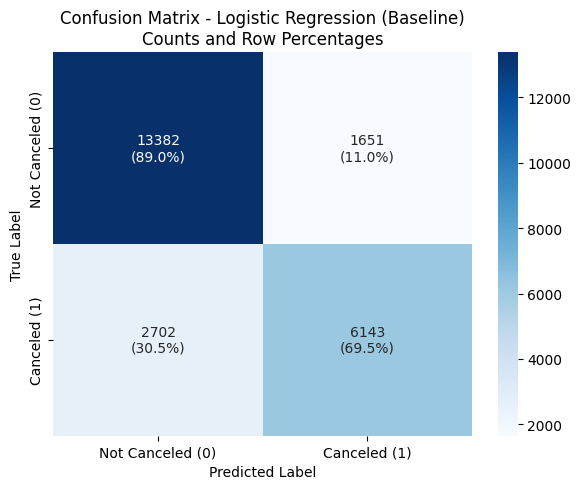

In [31]:
cm = confusion_matrix(y_test, y_pred)

# Convert to percentages (row-wise)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create annotation labels with count + percentage
labels = np.array([
    [f"{cm[i, j]}\n({cm_percent[i, j]*100:.1f}%)"
     for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["Not Canceled (0)", "Canceled (1)"],
    yticklabels=["Not Canceled (0)", "Canceled (1)"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression (Baseline)\nCounts and Row Percentages")
plt.tight_layout()
plt.show()


If the goal is to proactively manage cancellation risk, improving cancellation recall (currently 69.5%) should be the focus in the next modeling step (Try tree based model)

The model performs very well at identifying bookings that will not cancel.
However, it misses nearly one-third of actual cancellations.

This confirms what we saw in the classification report:

- Strong performance on class 0 (not canceled)

- Moderate recall for class 1 (canceled)

## ROC

The ROC curve shows how well the model can tell the difference between canceled and non-canceled bookings across all possible decision thresholds. Since the curve stays far above the diagonal line (which represents random guessing), it means the model is doing a good job separating the two classes.

The AUC of 0.892 indicates strong performance — in simple terms, the model can correctly rank a canceled booking higher than a non-canceled booking about 89% of the time.

This means the model has good overall predictive ability

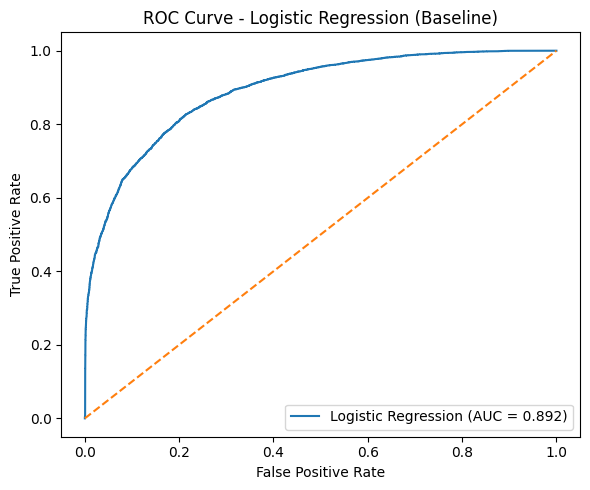


ROC-AUC Score: 0.8917


In [32]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Baseline)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Hyperparameters: L1 LASSO

hyperparameter we evaluated was the regularization type, specifically using L1 (LASSO) instead of the default L2 penalty. L1 regularization shrinks some coefficients all the way to zero, which performs automatic feature selection. This is useful because our dataset contains many one-hot encoded variables.

In [33]:
lasso_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",   # required for L1
    max_iter=1000,
    random_state=42
)

lasso_model.fit(X_train_enc, y_train)

# Predictions
y_pred_l1 = lasso_model.predict(X_test_enc)
y_prob_l1 = lasso_model.predict_proba(X_test_enc)[:, 1]


# Evaluation
print("=== LASSO (L1) Classification Report ===")
print(classification_report(y_test, y_pred_l1))

print("LASSO AUC:", roc_auc_score(y_test, y_prob_l1))

=== LASSO (L1) Classification Report ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86     15033
           1       0.79      0.69      0.74      8845

    accuracy                           0.82     23878
   macro avg       0.81      0.79      0.80     23878
weighted avg       0.82      0.82      0.81     23878

LASSO AUC: 0.8918395771999923


Before LASSO, the baseline Logistic Regression had a ROC-AUC of 0.8917. After applying L1 (LASSO) regularization, the ROC-AUC was 0.8918, which is essentially the same.

## Final Summary – Logistic Regression (Baseline)

The Logistic Regression model delivers strong overall performance, achieving 82% accuracy and an AUC of 0.89, indicating solid ability to distinguish between bookings that will cancel and those that will not. The model is particularly reliable at identifying non-cancellations, providing stability in operational forecasting.

However, it misses approximately 30% of actual cancellations, limiting its effectiveness for proactive revenue protection. While its predictions are generally dependable, its linear structure restricts its ability to capture more complex behavioral patterns within the data.

Next Step

Introduce a more flexible model, such as Random Forest, which can capture nonlinear relationships and interactions between booking characteristics.

# Week 7

# 6. Random Forest

## Random Forest (No Tuning)



In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score



In [35]:
# Tuned RF — only change: class_weight="balanced" to improve recall
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_train_enc, y_train)
# Predictions
y_pred_rf_tuned = rf_tuned.predict(X_test_enc)
y_prob_rf_tuned = rf_tuned.predict_proba(X_test_enc)[:, 1]

# Classification report
    

# Random Forest (with adjustment)
To improve cancellation recall, we tune the Random Forest by setting `class_weight="balanced"`. 200 trees.
This tells the model to give more weight to the minority class (canceled bookings), which directly
addresses the baseline model's weakness of missing ~30% of cancellations.

In [36]:
print("\n===== Classification Report — Tuned Random Forest =====\n")
print(classification_report(y_test, y_pred_rf_tuned))



===== Classification Report — Tuned Random Forest =====

              precision    recall  f1-score   support

           0       0.89      0.94      0.92     15033
           1       0.89      0.81      0.85      8845

    accuracy                           0.89     23878
   macro avg       0.89      0.87      0.88     23878
weighted avg       0.89      0.89      0.89     23878



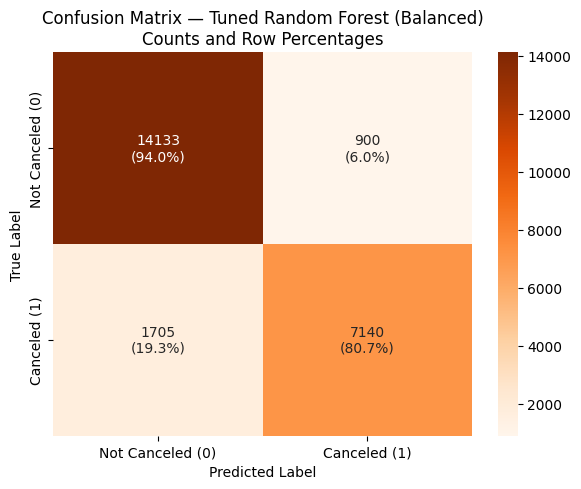

In [37]:
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

cm_rf_tuned_pct = cm_rf_tuned.astype('float') / cm_rf_tuned.sum(axis=1)[:, np.newaxis]

labels_rf_tuned = np.array([
    [f"{cm_rf_tuned[i, j]}\n({cm_rf_tuned_pct[i, j]*100:.1f}%)"
     for j in range(cm_rf_tuned.shape[1])]
    for i in range(cm_rf_tuned.shape[0])
])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf_tuned,
    annot=labels_rf_tuned,
    fmt="",
    cmap="Oranges",
    xticklabels=["Not Canceled (0)", "Canceled (1)"],
    yticklabels=["Not Canceled (0)", "Canceled (1)"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Tuned Random Forest (Balanced)\nCounts and Row Percentages")
plt.tight_layout()
plt.show()


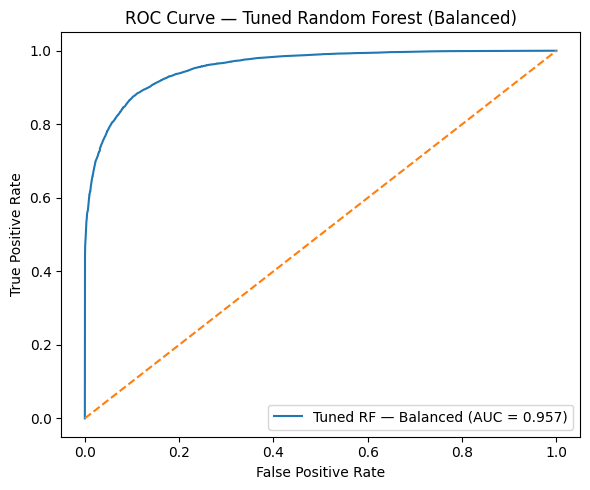


ROC-AUC Score: 0.9573


In [38]:
fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, y_prob_rf_tuned)
auc_rf_tuned = roc_auc_score(y_test, y_prob_rf_tuned)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf_tuned, tpr_rf_tuned, label=f"Tuned RF — Balanced (AUC = {auc_rf_tuned:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Tuned Random Forest (Balanced)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nROC-AUC Score: {auc_rf_tuned:.4f}")


# Week 8_1




## HistGradientBoostingClassifier

### Convert encoded features to dense arrays

In [39]:
if hasattr(X_train_enc, "toarray"):
    X_train_dense = X_train_enc.toarray()
else:
    X_train_dense = X_train_enc

if hasattr(X_test_enc, "toarray"):
    X_test_dense = X_test_enc.toarray()
else:
    X_test_dense = X_test_enc

print("X_train_dense shape:", X_train_dense.shape)
print("X_test_dense shape:", X_test_dense.shape)

X_train_dense shape: (95512, 221)
X_test_dense shape: (23878, 221)


### Train a baseline HistGradientBoosting model


In [40]:
hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

hgb_model.fit(X_train_dense, y_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",6
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtyp

### classfication & report


In [41]:
y_pred_hgb = hgb_model.predict(X_test_dense)
y_prob_hgb = hgb_model.predict_proba(X_test_dense)[:, 1]

In [42]:
print("===== HistGradientBoosting Classification Report =====")
print(classification_report(y_test, y_pred_hgb))

===== HistGradientBoosting Classification Report =====
              precision    recall  f1-score   support

           0       0.88      0.91      0.89     15033
           1       0.83      0.78      0.81      8845

    accuracy                           0.86     23878
   macro avg       0.86      0.85      0.85     23878
weighted avg       0.86      0.86      0.86     23878



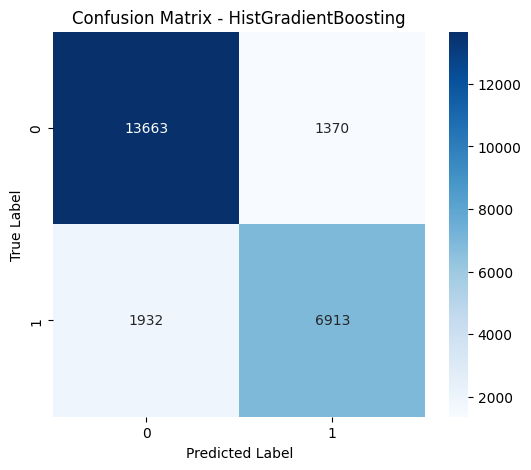

In [43]:

cm_hgb = confusion_matrix(y_test, y_pred_hgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_hgb, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - HistGradientBoosting")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

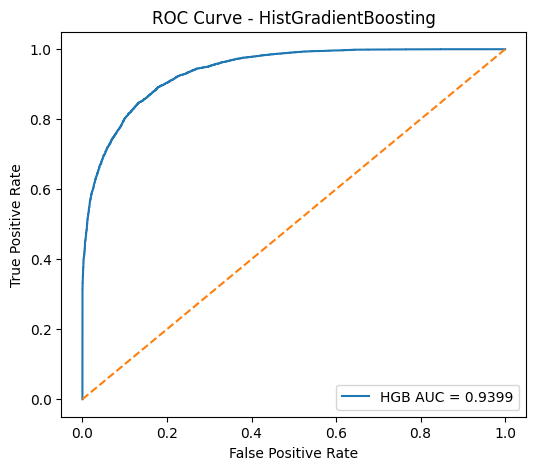

HistGradientBoosting ROC-AUC: 0.9398869011633987


In [44]:

fpr_hgb, tpr_hgb, _ = roc_curve(y_test, y_prob_hgb)
auc_hgb = roc_auc_score(y_test, y_prob_hgb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_hgb, tpr_hgb, label=f"HGB AUC = {auc_hgb:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - HistGradientBoosting")
plt.legend()
plt.show()

print("HistGradientBoosting ROC-AUC:", auc_hgb)

### Fine Tuning HistGradientBoosting model

In [45]:
hgb_tuned = HistGradientBoostingClassifier(
    learning_rate=0.03,
    max_iter=500,
    max_depth=8,
    min_samples_leaf=15,
    l2_regularization=1.0,
    random_state=42
)

hgb_tuned.fit(X_train_dense, y_train)

y_pred_hgb_tuned = hgb_tuned.predict(X_test_dense)
y_prob_hgb_tuned = hgb_tuned.predict_proba(X_test_dense)[:, 1]

print("===== Tuned HistGradientBoosting Classification Report =====")
print(classification_report(y_test, y_pred_hgb_tuned))

auc_hgb_tuned = roc_auc_score(y_test, y_prob_hgb_tuned)
print("Tuned HistGradientBoosting ROC-AUC:", auc_hgb_tuned)

===== Tuned HistGradientBoosting Classification Report =====
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     15033
           1       0.84      0.79      0.81      8845

    accuracy                           0.87     23878
   macro avg       0.86      0.85      0.86     23878
weighted avg       0.87      0.87      0.87     23878

Tuned HistGradientBoosting ROC-AUC: 0.9424247736569898


# Week 8_2 XGBoost model

In [46]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [47]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

## Baseline XGBoost


In [48]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_enc, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_enc)
y_prob_xgb = xgb_model.predict_proba(X_test_enc)[:, 1]

In [49]:
print("===== XGBoost Classification Report =====")
print(classification_report(y_test, y_pred_xgb))

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("XGBoost ROC-AUC:", auc_xgb)

===== XGBoost Classification Report =====
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     15033
           1       0.85      0.79      0.81      8845

    accuracy                           0.87     23878
   macro avg       0.86      0.85      0.86     23878
weighted avg       0.87      0.87      0.87     23878

XGBoost ROC-AUC: 0.9437467531859531


In terms of class-wise performance, the model achieves a precision of 0.88 and recall of 0.92 for non-canceled bookings (class 0), indicating that it is highly effective at correctly identifying bookings that will not be canceled. For canceled bookings (class 1), the model attains a precision of 0.85 and recall of 0.79, suggesting slightly weaker performance in capturing cancellations, with some false negatives remaining.

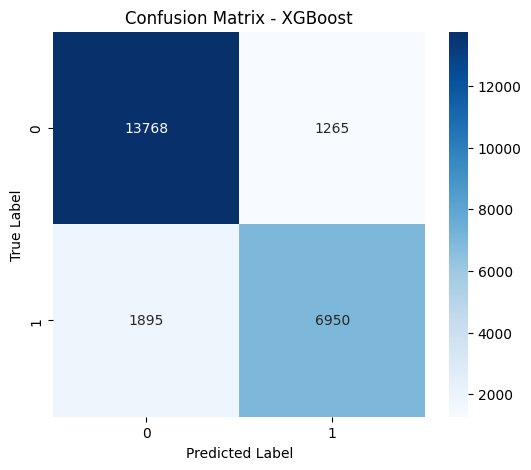

In [50]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

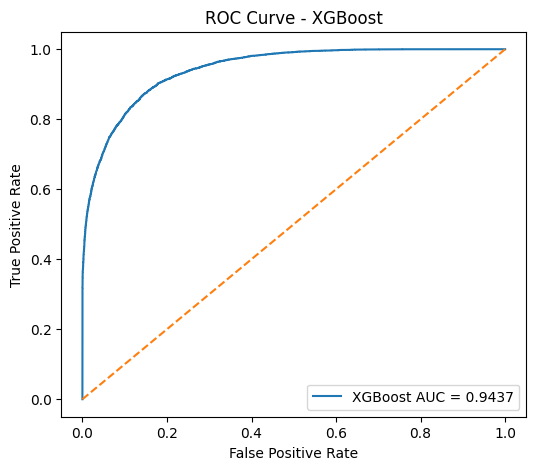

In [51]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {auc_xgb:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

## tuned_XGBoost


In [52]:
xgb_tuned = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
    use_label_encoder=False
)

xgb_tuned.fit(X_train_enc, y_train)

y_pred_xgb_tuned = xgb_tuned.predict(X_test_enc)
y_prob_xgb_tuned = xgb_tuned.predict_proba(X_test_enc)[:, 1]

print("===== Tuned XGBoost Classification Report =====")
print(classification_report(y_test, y_pred_xgb_tuned))

auc_xgb_tuned = roc_auc_score(y_test, y_prob_xgb_tuned)
print("Tuned XGBoost ROC-AUC:", auc_xgb_tuned)

===== Tuned XGBoost Classification Report =====
              precision    recall  f1-score   support

           0       0.89      0.92      0.90     15033
           1       0.86      0.80      0.83      8845

    accuracy                           0.88     23878
   macro avg       0.87      0.86      0.87     23878
weighted avg       0.88      0.88      0.88     23878

Tuned XGBoost ROC-AUC: 0.9501890564707145


Notably, the increase in recall for class 1 suggests that the tuned model is more effective at capturing true cancellations, which is often critical in operational decision-making contexts such as overbooking management or revenue optimization. At the same time, the model maintains strong precision, indicating that the improvement does not come at the cost of excessive false alarms.

Overall, the tuned XGBoost model outperforms the baseline version across all key metrics, particularly in ROC-AUC and class 1 recall. This confirms that hyperparameter tuning significantly enhances model performance. Given its strong predictive accuracy and balanced classification behavior, the tuned XGBoost model can be considered the best-performing model in this analysis and a strong candidate for deployment.

# Week10 data-centric AI in XGBoost


In [53]:
xgb_final = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
    use_label_encoder=False
)

In [54]:
xgb_final.fit(X_train_enc, y_train)

y_prob_base = xgb_final.predict_proba(X_test_enc)[:, 1]
auc_base = roc_auc_score(y_test, y_prob_base)

print("Baseline AUC:", auc_base)

Baseline AUC: 0.9501890564707145


## handle class imbalance

In [55]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_balanced = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False
)

xgb_balanced.fit(X_train_enc, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [56]:
y_pred_bal = xgb_balanced.predict(X_test_enc)
y_prob_bal = xgb_balanced.predict_proba(X_test_enc)[:, 1]

## Balanced XGBoost

In [57]:

print("===== Balanced XGBoost Classification Report =====")
print(classification_report(y_test, y_pred_bal))

===== Balanced XGBoost Classification Report =====
              precision    recall  f1-score   support

           0       0.92      0.87      0.90     15033
           1       0.80      0.87      0.83      8845

    accuracy                           0.87     23878
   macro avg       0.86      0.87      0.87     23878
weighted avg       0.88      0.87      0.87     23878



In [58]:

auc_bal = roc_auc_score(y_test, y_prob_bal)
print("Balanced XGBoost ROC-AUC:", auc_bal)

Balanced XGBoost ROC-AUC: 0.9503968864127335


In [59]:
print("Baseline AUC:", auc_base)
print("Balanced AUC:", auc_bal)

Baseline AUC: 0.9501890564707145
Balanced AUC: 0.9503968864127335


The results show a meaningful shift in classification behavior. Specifically, the recall for the cancellation class (class 1) improved from 0.80 to 0.87, indicating that the model is now significantly better at identifying true cancellations. This is a critical improvement for practical applications such as revenue management, where missing cancellations can be costly.

However, this improvement comes with a trade-off: the precision for class 1 decreased from 0.86 to 0.80, and the recall for non-canceled bookings (class 0) dropped from 0.92 to 0.87. This indicates that the model becomes more aggressive in predicting cancellations, leading to more false positives.

Importantly, the overall ROC-AUC slightly increased from 0.9502 to 0.9504, suggesting a marginal improvement in the model’s overall discriminative ability. While the gain in AUC is small, the substantial increase in recall for class 1 highlights a meaningful improvement in capturing the minority class.

## Edited Week 9 Select Best Model with XG Boost added



In [61]:
# Dictionary: model_name -> (model, X_data)  for training predictions
models_info = {
    "Logistic Regression":          (log_model,     X_train_enc),
    "Random Forest (balanced)":     (rf_tuned,      X_train_enc),
    "HistGradientBoosting":         (hgb_model,     X_train_dense),
    "HistGradientBoosting (tuned)": (hgb_tuned,     X_train_dense),
    "XGBoost (baseline)":           (xgb_model,     X_train_enc),
    "XGBoost (tuned)":              (xgb_tuned,     X_train_enc),
    "XGBoost (balanced)":           (xgb_balanced,  X_train_enc),
}

train_rows = []
for name, (model, X_data) in models_info.items():
    preds = model.predict(X_data)
    probs = model.predict_proba(X_data)[:, 1]
    train_rows.append({
        "Model":       name,
        "Accuracy":    round(accuracy_score(y_train, preds), 4),
        "Precision":   round(precision_score(y_train, preds), 4),
        "Recall":      round(recall_score(y_train, preds), 4),
        "F1-Score":    round(f1_score(y_train, preds), 4),
        "ROC-AUC":     round(roc_auc_score(y_train, probs), 4),
    })

train_df = pd.DataFrame(train_rows).set_index("Model")

print("=" * 70)
print("         Model Comparison Table (Training Set)")
print("=" * 70)
display(train_df)

         Model Comparison Table (Training Set)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8175,0.7841,0.6999,0.7396,0.8936
Random Forest (balanced),0.9961,0.9935,0.9961,0.9948,0.9996
HistGradientBoosting,0.8664,0.8385,0.7919,0.8145,0.9441
HistGradientBoosting (tuned),0.8723,0.8489,0.7972,0.8222,0.9474
XGBoost (baseline),0.8762,0.8538,0.8032,0.8277,0.9512
XGBoost (tuned),0.8942,0.8800,0.8272,0.8527,0.9638
XGBoost (balanced),0.8909,0.8222,0.9003,0.8595,0.9645


RF overfit as mention before.  
XGBoost(tunned) wins as the best model therefore we see it's performance on the test set next: 

In [60]:

# compare the models (just to inspect rf)
# Dictionary: model_name -> (y_pred, y_prob)
model_results = {
    "Logistic Regression":       (log_model.predict(X_test_enc),
                                  log_model.predict_proba(X_test_enc)[:, 1]),
    "Random Forest (balanced)":  (rf_tuned.predict(X_test_enc),
                                  rf_tuned.predict_proba(X_test_enc)[:, 1]),
    "HistGradientBoosting":      (hgb_model.predict(X_test_dense),
                                  hgb_model.predict_proba(X_test_dense)[:, 1]),
    "HistGradientBoosting (tuned)": (hgb_tuned.predict(X_test_dense),
                                     hgb_tuned.predict_proba(X_test_dense)[:, 1]),
    "XGBoost (baseline)":        (xgb_model.predict(X_test_enc),
                                  xgb_model.predict_proba(X_test_enc)[:, 1]),
    "XGBoost (tuned)":           (xgb_tuned.predict(X_test_enc),
                                  xgb_tuned.predict_proba(X_test_enc)[:, 1]),
    "XGBoost (balanced)":        (xgb_balanced.predict(X_test_enc),
                                  xgb_balanced.predict_proba(X_test_enc)[:, 1]),
}

rows = []
for name, (preds, probs) in model_results.items():
    rows.append({
        "Model":       name,
        "Accuracy":    round(accuracy_score(y_test, preds), 4),
        "Precision":   round(precision_score(y_test, preds), 4),
        "Recall":      round(recall_score(y_test, preds), 4),
        "F1-Score":    round(f1_score(y_test, preds), 4),
        "ROC-AUC":     round(roc_auc_score(y_test, probs), 4),
    })

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.set_index("Model")

print("="*70)
print("           Model Comparison Table (Test Set)")
print("="*70)
display(comparison_df)


           Model Comparison Table (Test Set)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8177,0.7882,0.6945,0.7384,0.8917
Random Forest (balanced),0.8909,0.8881,0.8072,0.8457,0.9573
HistGradientBoosting,0.8617,0.8346,0.7816,0.8072,0.9399
HistGradientBoosting (tuned),0.8671,0.8449,0.7853,0.8140,0.9424
XGBoost (baseline),0.8677,0.8460,0.7858,0.8148,0.9437
XGBoost (tuned),0.8763,0.8582,0.7980,0.8270,0.9502
XGBoost (balanced),0.8721,0.8011,0.8709,0.8346,0.9504


The Tuned XGBoost model achieves an overall accuracy of 87.63% on the test set, correctly classifying the majority of both canceled and non-canceled bookings. With a precision of 0.8582, approximately 86% of the bookings predicted as cancellations are indeed true cancellations, meaning the model generates relatively few false alarms. The recall of 0.7980 indicates that the model successfully identifies about 80% of all actual cancellations, though roughly 20% of true cancellations are still missed. The F1-Score of 0.8270 reflects a strong and well-balanced trade-off between precision and recall, suggesting the model does not heavily favor one at the expense of the other. Most importantly, the ROC-AUC of 0.9502 demonstrates excellent discriminative ability — the model can distinguish between canceled and non-canceled bookings with high confidence across all classification thresholds. Overall, these results confirm that the Tuned XGBoost is the best-performing model in this analysis and is well-suited for practical deployment in hotel cancellation prediction tasks.